# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [58]:
import torch

from src.pca import fit_pca, transform_pca, reconstruct_pca
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from src.utils import DATA_PATH, RANDOM_SEED, train_val_split, df_to_np, standardize, select_subset_classes, INPUT_SIZE
from src.plots import plot_images, plot_class_distribution, plot_images_by_class, plot_explained_variance, \
    plot_reconstruction_comparison, plot_scatter_2d, plot_silhouette_comparison, plot_elbow_method
from src.autoencoder import ModelConfig, compare_models
from typing import List
from src.metrics import mse, silhouette_score
from src.kmeans import kmeans
from src.gmm import gmm

np.random.seed(RANDOM_SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Inspección de los datos

**a) Implementar una función que pueda graficar un número
   arbitrario de imágenes del dataset. Mostrar un ejemplo
   de un gráfico con 15 imágenes seleccionadas de manera
  aleatoria. Esta función va a ser necesaria a lo largo
  de todo el trabajo, por lo que se deberá ir adaptando
  de acuerdo a las necesidades que vayan surgiendo.**

In [2]:
df = pd.read_csv(DATA_PATH)

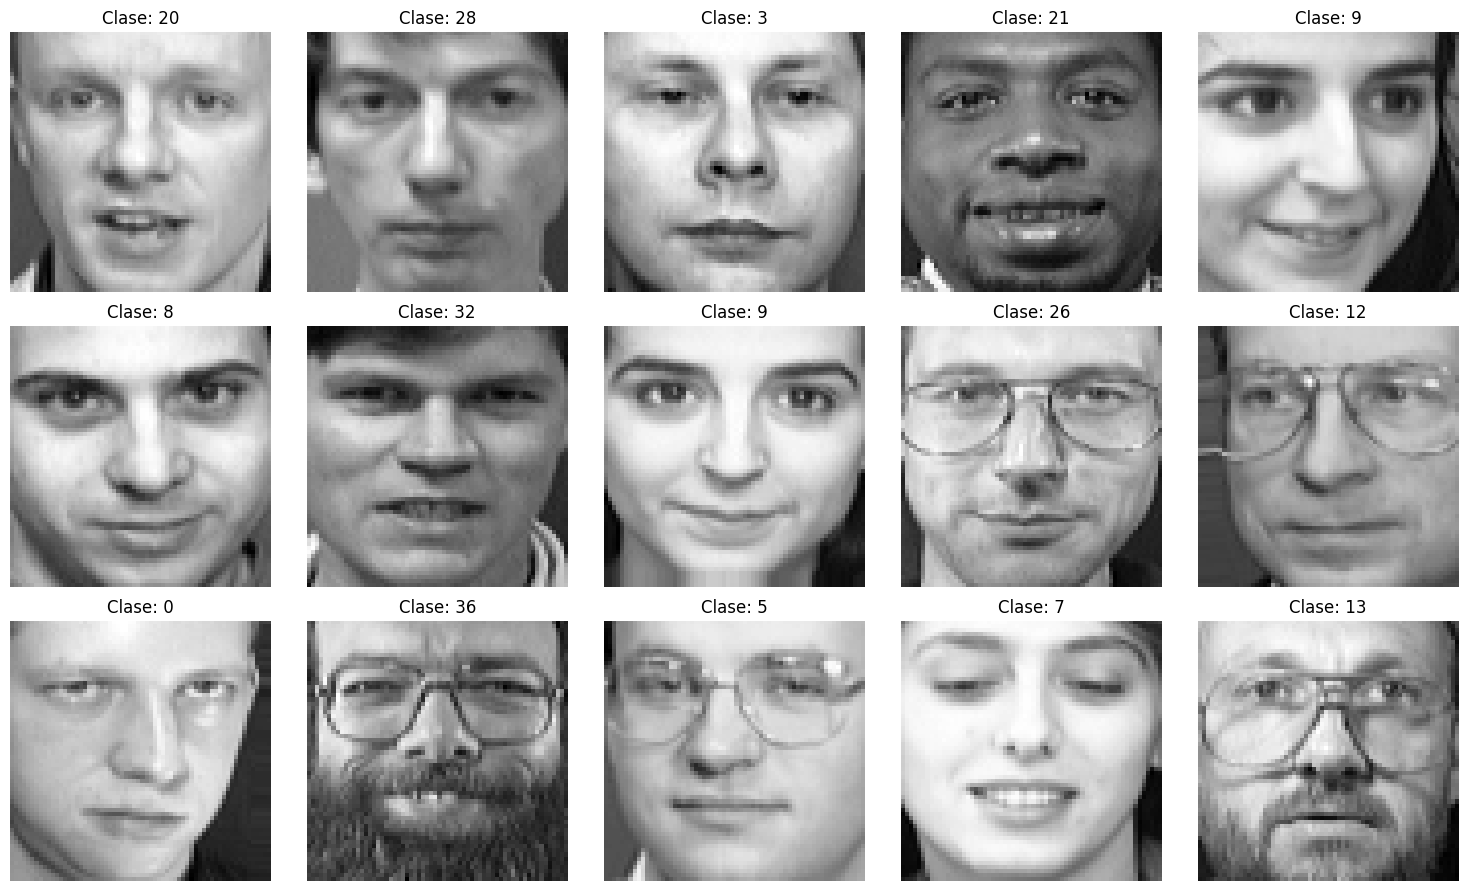

In [3]:
plot_images(df, n=15, ncols=5, filename="1_initial_faces")

**b) Realizar un analisis exploratorio enfocado en
  la distribución de clases en los datos. Para
  tener una mejor noción de la variabilidad de las
  muestras, graficar muestras agrupadas por clase,
  para al menos 5 clases.**

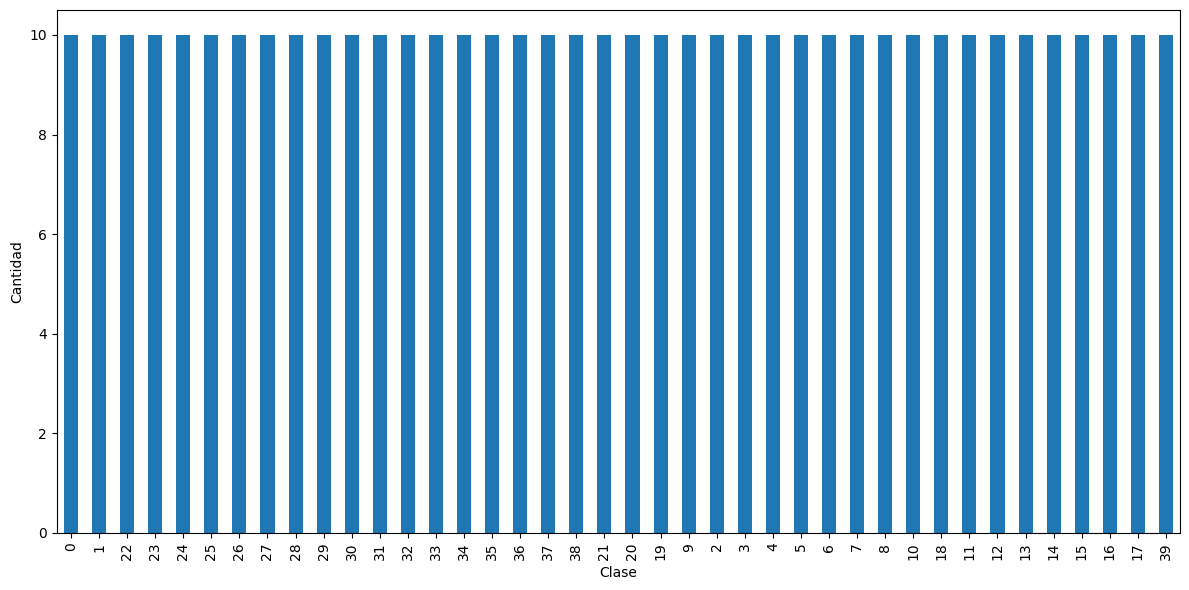

In [4]:
plot_class_distribution(df, figsize=(12,6), filename="2_class_distribution")

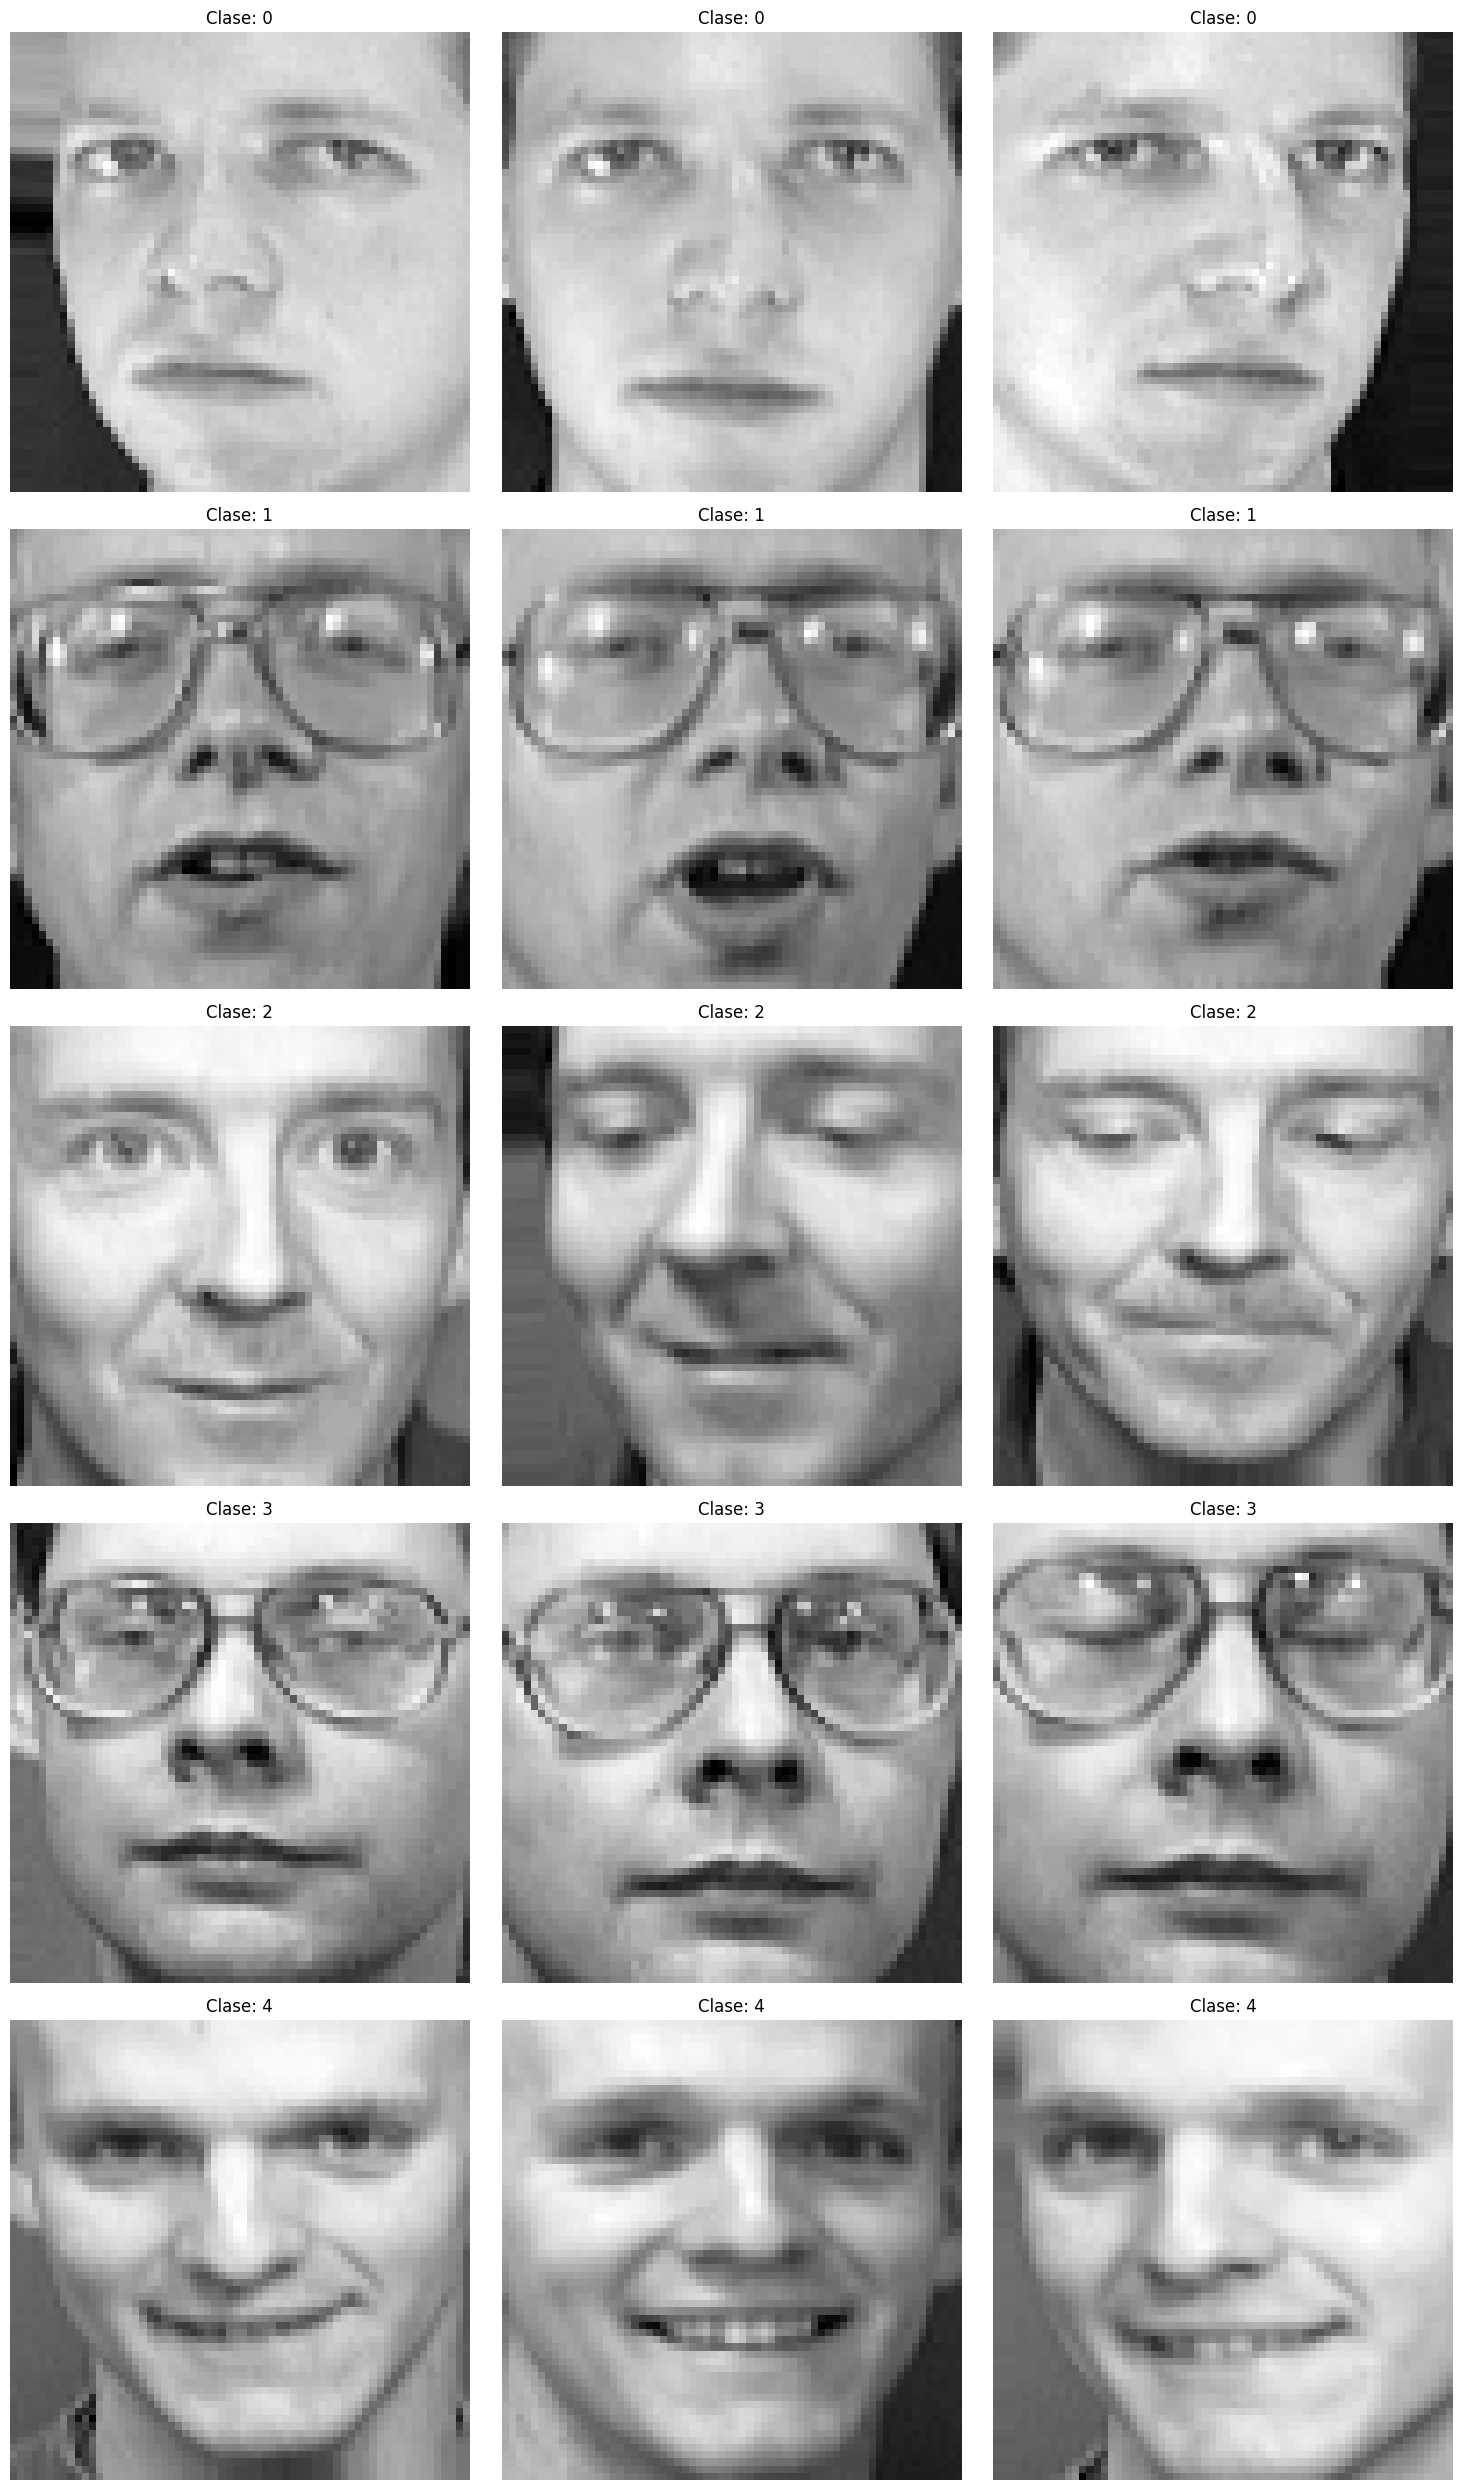

In [5]:
plot_images_by_class(df, n_classes=5, n_per_class=3, filename="3_initial_faces_by_class")

  **c) Realizar un split de datos estratificado para
  conformar un conjunto de entrenamiento y otro de
  evaluación, en donde los datos de evaluación sean
   el 20 % del total.**

In [6]:
df_train, df_val = train_val_split(df, val_size=0.2)
df_train.shape

(320, 4097)

## 2. Reducción de dimensionalidad

**a) Implementar una función para estandarizar los
  datos, y otra para realizar Principal Component
  Analysis (PCA). Estandarizar y aplicar PCA sobre
  los datos de entrenamiento. Con la transformacion
   aprendida previamente reducir la dimensionalidad
   de los datos de evaluacion.**

In [7]:
# primero convertimos a numpy
X, y = df_to_np(df_train)

# estandarizamos
X_std, X_mu, X_sigma = standardize(X)

# calculamos:
# W = autovectores como columnas
# lambdas = autovalores
# varianza explicada por cada componente principal
lambdas, W, explained_variance_ratios = fit_pca(X_std)

# transformamos sin reducir dimensionalidad
Z_full = transform_pca(X_std, W)

b) Realizar un gráfico que muestre la varianza
  explicada acumulada en función del número de
  componentes. Conservar el número de componentes
  que aseguren explicar el 90 % de la varianza de
  los datos. Utilizando la función aprendida en el
  punto 1.a), realizar un gráfico comparativo entre
   las imágenes originales y la reconstrucción
  partiendo del número de componentes determinado
  anteriormente.

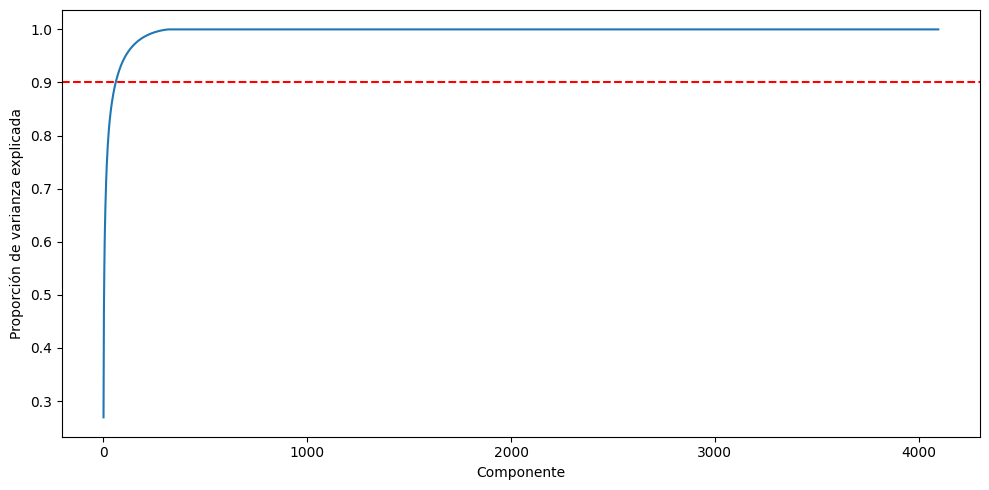

In [8]:
plot_explained_variance(explained_variance_ratios, filename="4_explained_variance")

In [9]:
threshold_component = np.argmax(np.cumsum(explained_variance_ratios) >= 0.90) + 1

print(f"Las primeras {threshold_component} componentes principales explican el 90% de la varianza")

Las primeras 61 componentes principales explican el 90% de la varianza


In [10]:
LATENT_SIZE = int(threshold_component)
Z_reduced = transform_pca(X_std, W, LATENT_SIZE)
X_reconstructed = reconstruct_pca(Z_reduced, W, X_mu, X_sigma, LATENT_SIZE)

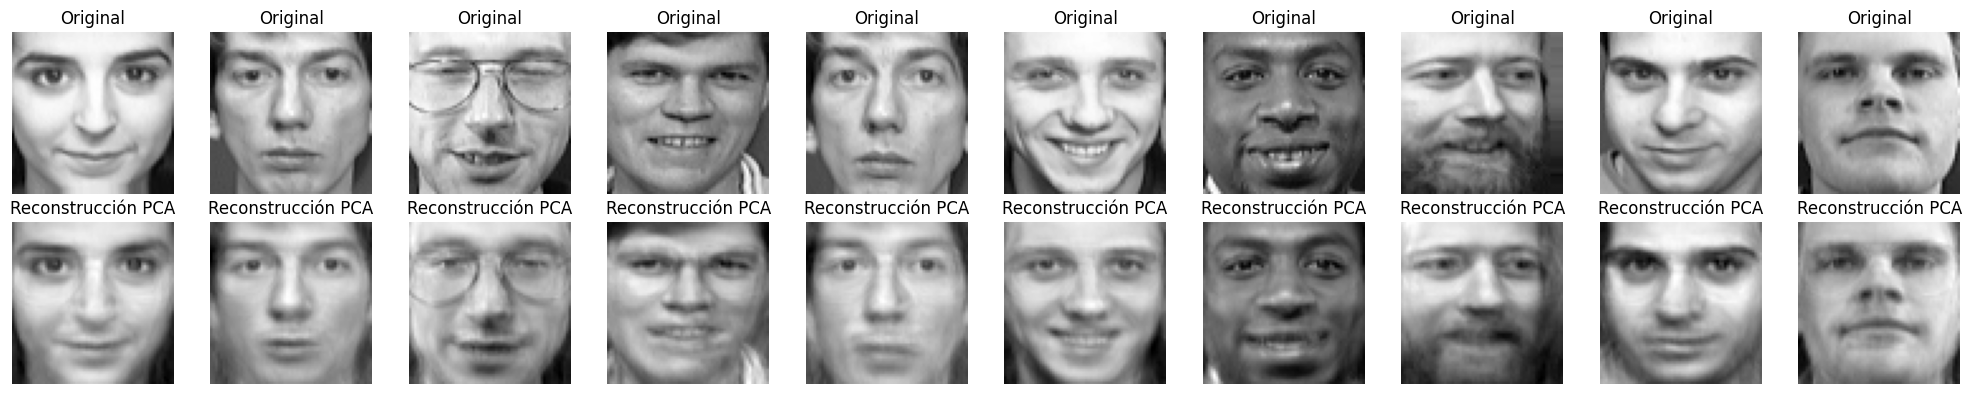

In [11]:
plot_reconstruction_comparison(X, X_reconstructed, n_images=10, filename="5_reconstruction_comparison")

In [12]:
mse_pca = mse(X, X_reconstructed)
print(f"El error de reconstrucción del PCA es: {mse_pca}")

El error de reconstrucción del PCA es: 0.00196018237003768


Prueba: reducir a 2d y graficar

Unique labels: [0 1 2 3 4 5 6 7 8 9]


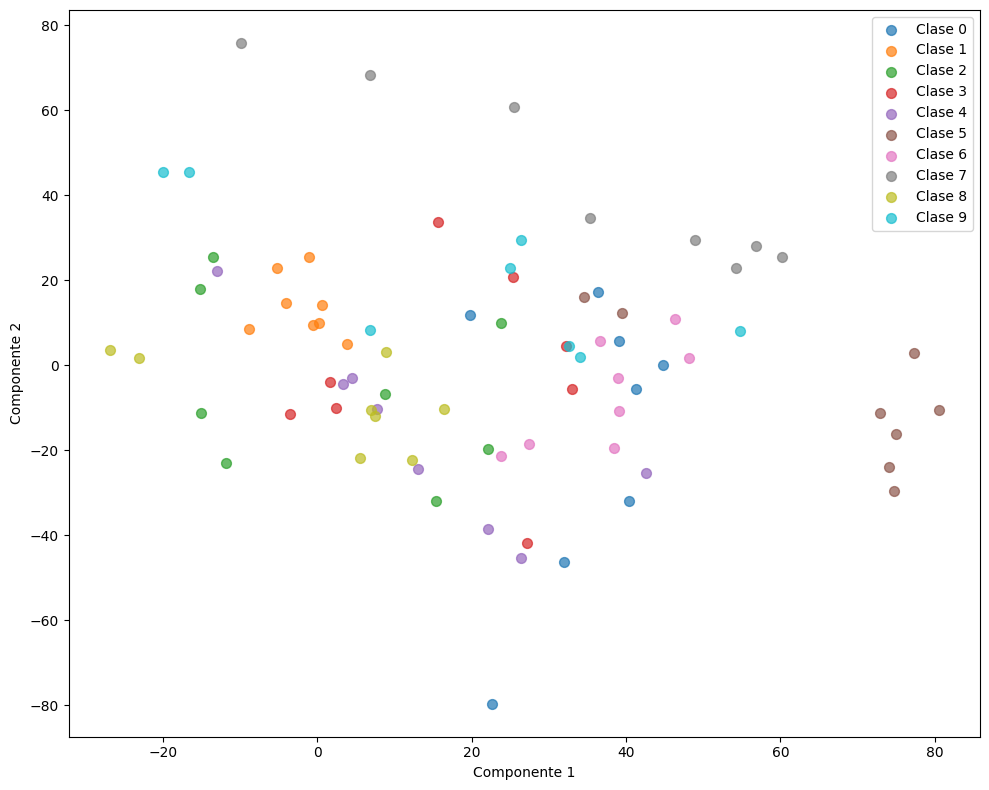

In [13]:
Z_2 = transform_pca(X_std, W, 2)
Z_2_subset, y_subset = select_subset_classes(Z_2, y, 10)
plot_scatter_2d(Z_2_subset, y_subset, xlabel="Componente 1", ylabel="Componente 2", filename="6_pca_2d")

**c) Entrenar un modelo de autoencoder
  deterministico (AE) utilizando la librería
  PyTorch para armar y entrenar las redes
  neuronales involucradas (la red de encoder y la
  de decoder). Para hacer una comparacion justa, la
   dimension latente debe ser la misma que la
  obtenida en el PCA. Recuerde dividir el conjunto
  de datos en dos subconjuntos: entrenamiento y
  validación, los mismos utilizados para el PCA. El
   subconjunto de entrenamiento se empleará para
  entrenar el AE, mientras que el de validación
  servirá para ajustar los hiperparámetros
  (regularizacion, arquitectura o lo que considere)
   y evaluar el error de reconstrucción.**

In [14]:
X_val, y_val = df_to_np(df_val)
X_val_std, _, _ = standardize(X_val, X_mu, X_sigma)

# Probamos varias arquitecturas  & dropouts
configs: List[ModelConfig] = [
    ModelConfig(
        encoder_layers=[512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512],
        dropout=0.0,
        lr=0.001,
        name="mini",
    ),
    ModelConfig(
        encoder_layers=[1024],
        latent_size=LATENT_SIZE,
        decoder_layers=[1024],
        dropout=0.0,
        lr=0.001,
        name="narrow_shallow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048],
        dropout=0.1,
        lr=0.0001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[3072],
        latent_size=LATENT_SIZE,
        decoder_layers=[3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048],
        dropout=0.2,
        lr=0.001,
        name="wide_deep_dropout_02",
    ),
    ModelConfig(
        encoder_layers=[2048, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 2048],
        dropout=0.1,
        lr=0.001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[1024, 256],
        latent_size=LATENT_SIZE,
        decoder_layers=[256, 1024],
        dropout=0.0,
        lr=0.001,
        name="ultranarrow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048, 3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_03",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048, 3072],
        dropout=0.3,
        lr=0.005,
        name="ultrawide_deep_dropout_04",

    )
]

results, best_model = compare_models(configs, X_std, X_val_std, epochs=500, input_size=INPUT_SIZE)

Training model: mini
Epoch 1/500, Train Loss: 1.0036, Val Loss: 1.1468
Epoch 11/500, Train Loss: 0.5809, Val Loss: 0.5755
Epoch 21/500, Train Loss: 0.4293, Val Loss: 0.4523
Epoch 31/500, Train Loss: 0.3371, Val Loss: 0.3687
Epoch 41/500, Train Loss: 0.2711, Val Loss: 0.3159
Epoch 51/500, Train Loss: 0.2243, Val Loss: 0.2810
Epoch 61/500, Train Loss: 0.1911, Val Loss: 0.2605
Epoch 71/500, Train Loss: 0.1647, Val Loss: 0.2434
Epoch 81/500, Train Loss: 0.1446, Val Loss: 0.2324
Epoch 91/500, Train Loss: 0.1285, Val Loss: 0.2244
Epoch 101/500, Train Loss: 0.1150, Val Loss: 0.2186
Epoch 111/500, Train Loss: 0.1053, Val Loss: 0.2147
Epoch 121/500, Train Loss: 0.0938, Val Loss: 0.2117
Epoch 131/500, Train Loss: 0.0850, Val Loss: 0.2090
Epoch 141/500, Train Loss: 0.0772, Val Loss: 0.2071
Epoch 151/500, Train Loss: 0.0707, Val Loss: 0.2063
Epoch 161/500, Train Loss: 0.0657, Val Loss: 0.2071
Epoch 171/500, Train Loss: 0.0594, Val Loss: 0.2053
Epoch 181/500, Train Loss: 0.0540, Val Loss: 0.2048
Ep

In [15]:
autoencoder = results[best_model]["model"]

autoencoder.eval()
with torch.no_grad():
    X_std_tensor = torch.tensor(X_std,dtype=torch.float32)
    X_reconstructed_ae = autoencoder.decode(autoencoder.encode(X_std_tensor, numpy=True), numpy=True) * X_sigma + X_mu

    mse_ae = mse(X, X_reconstructed_ae)
    print(f"El error de reconstrucción del AE es: {mse_ae}")


El error de reconstrucción del AE es: 0.0005123044543633267


 **d) Una vez desarrollado el AE, compare la calidad de las imágenes reconstruidas con
  las obtenidas mediante PCA en el inciso anterior, utilizando 10 imagenes tomadas
  aleatoriamente del conjunto de validación del AE.**

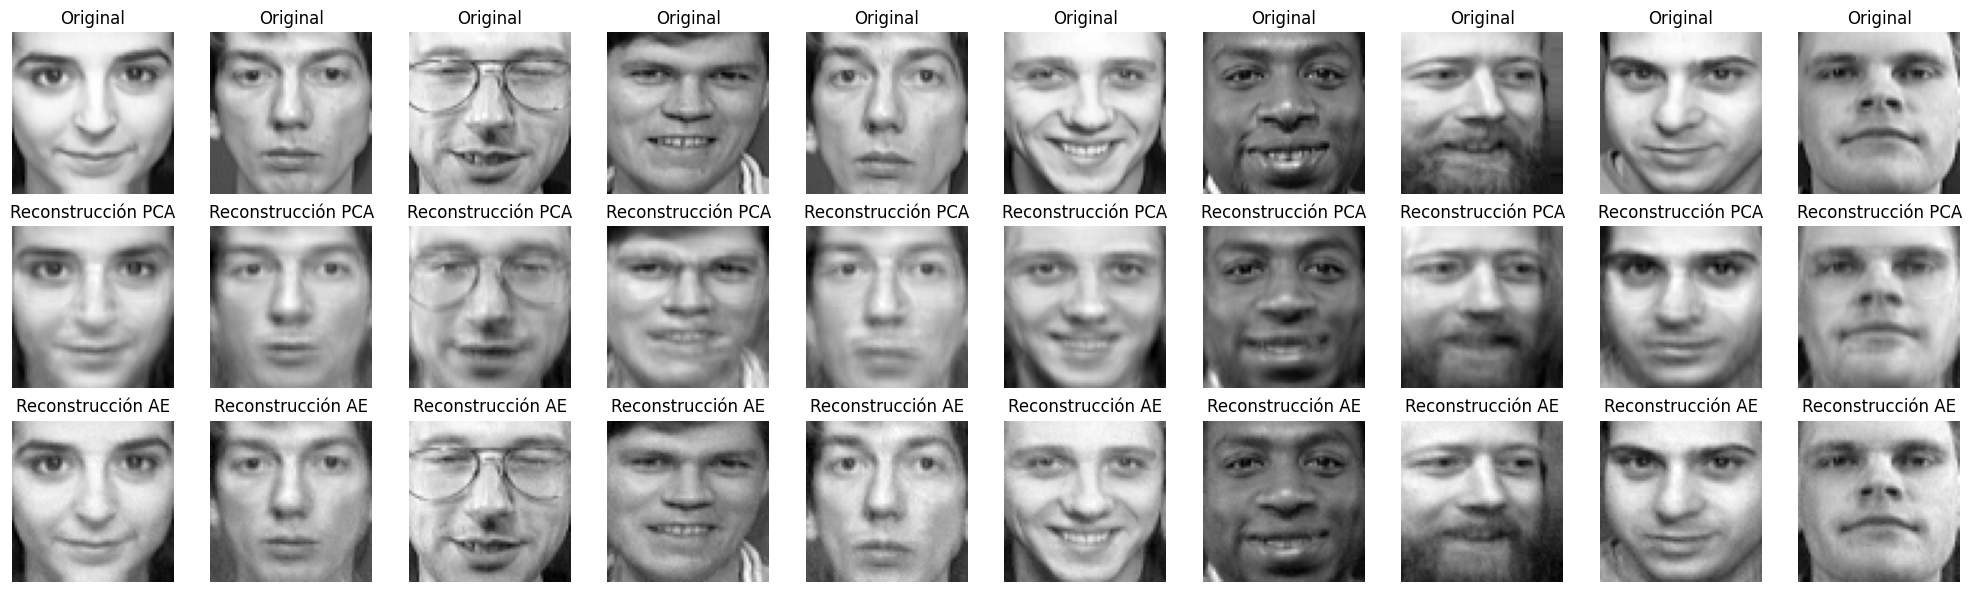

In [16]:
plot_reconstruction_comparison(X, X_reconstructed, X_reconstructed_ae, n_images=10, filename="7_reconstruction_comparison_ae")

 **e) Para los siguientes puntos, en lugar de trabajar con las imágenes originales vamos
  a trabajar con su versión de menor dimensionalidad en el espacio latente del PCA y AE
  obtenida en el inciso anterior para acelerar el procesamiento. Aplique la
  transformación para todos los datos, tanto de entrenamiento como de evaluación usando
  la transformacion aprendida con los datos de entrenamiento.**


In [17]:
autoencoder.eval()
with torch.no_grad():
    Z_train = autoencoder.encode(X_std, numpy=True)
    Z_val = autoencoder.encode(X_val_std, numpy=True)

## 3. Clustering
a) Desarrollar una funcion que implemente el
  algoritmo k-Means. Probar con valores de K
  dentro del rango de [5, 20].


In [60]:
kmeans_results = {}

K_RANGE = range(5, 21)

for i in K_RANGE:
    centroids, assignments, losses = kmeans(Z_train, i, max_iters=500)
    kmeans_results[i] = {
        "centroids": centroids,
        "assignments": assignments,
        "losses": losses,
        "silhouette_score": silhouette_score(Z_train, assignments),
    }

Iteration 0: loss = 339.2675007134817
Iteration 10: loss = 302.98224095354857
Converged at iteration 16
Iteration 0: loss = 334.405134695855
Converged at iteration 10
Iteration 0: loss = 316.37435142403626
Converged at iteration 9
Iteration 0: loss = 307.6322398005374
Converged at iteration 10
Iteration 0: loss = 299.7863814038241
Converged at iteration 7
Iteration 0: loss = 292.0755417467884
Converged at iteration 6
Iteration 0: loss = 281.3325153004785
Iteration 10: loss = 256.86228551670763
Converged at iteration 14
Iteration 0: loss = 278.8051012277163
Iteration 10: loss = 251.8036854489536
Converged at iteration 11
Iteration 0: loss = 275.3261001202708
Iteration 10: loss = 247.12762239198764
Converged at iteration 13
Iteration 0: loss = 271.5159228835493
Iteration 10: loss = 248.62328066748054
Converged at iteration 12
Iteration 0: loss = 270.95179702338453
Iteration 10: loss = 242.72231586712124
Converged at iteration 13
Iteration 0: loss = 269.9386559189023
Iteration 10: loss = 

In [52]:
gmm_results = {}

for i in K_RANGE:
    means, covariances, priors, assignments, log_likelihoods = gmm(Z_train, i, max_iters=500, tolerance=10)
    gmm_results[i] = {
        "means": means,
        "covariances": covariances,
        "priors": priors,
        "assignments": assignments,
        "log_likelihoods": log_likelihoods,
        "silhouette_score": silhouette_score(Z_train, assignments),
    }


Iteration 0: loss = 339.2675007134817
Iteration 10: loss = 302.98224095354857
Converged at iteration 16
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 334.405134695855
Converged at iteration 10
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 316.37435142403626
Converged at iteration 9
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 307.6322398005374
Converged at iteration 10
Iteration 0: log likelihood = -7368.272297580748
Converged at iteration 1
Iteration 0: loss = 299.7863814038241
Converged at iteration 7
Iteration 0: log likelihood = -7368.27229757946
Converged at iteration 1
Iteration 0: loss = 292.0755417467884
Converged at iteration 6
Iteration 0: log likelihood = -7368.272297483709
Converged at iteration 1
Iteration 0: loss = 281.3325153004785
Iteration 10: loss = 256.86228551670763
Converged at iteration 14
Iteration 0: log likelihood = -7

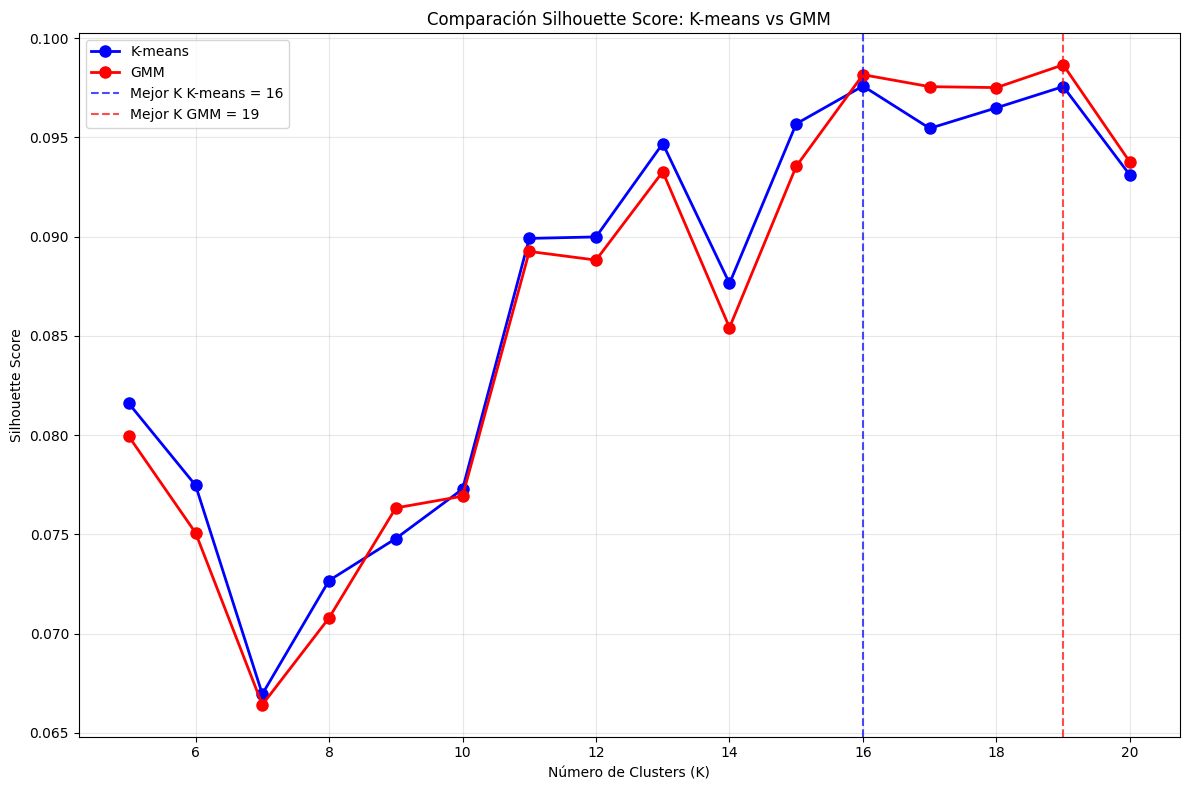

In [57]:
plot_silhouette_comparison(kmeans_results, gmm_results)

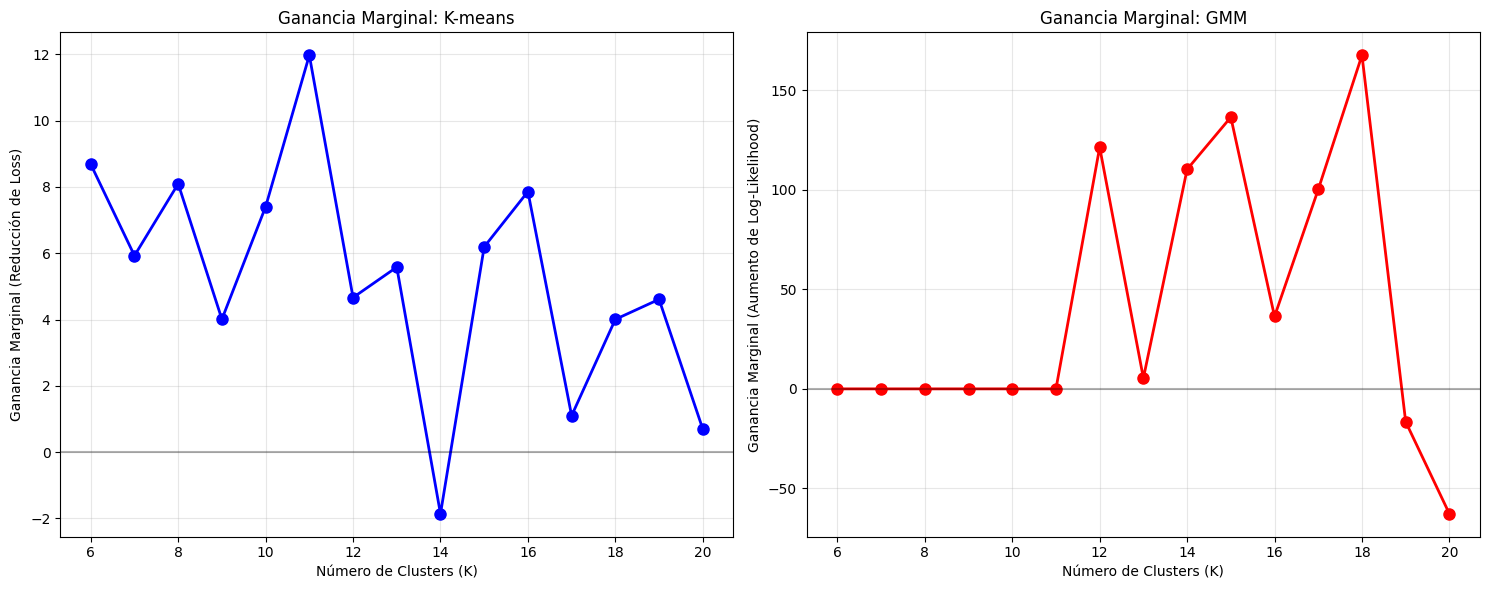

In [63]:
plot_elbow_method(kmeans_results, gmm_results, figsize=(15, 6), filename="8_elbow_method")